#Actividad 1: Análisis de correlación
Consigna:

Calcular la correlación entre precio y quilates de los diamantes color “F” y corte Premium.

Visualizar los resultados mediante gráfico de dispersión.

In [ ]:
import seaborn as sns

df_diamonds = sns.load_dataset("diamonds")

# Seleccionar diamantes de corte premiun y color F
df_diamonds_premium_f = df_diamonds[(df_diamonds['cut'] == 'Premium') & (df_diamonds['color'] == 'F')].reset_index(drop=True)

# Filtrar columnas precio y kilates
df_diamonds_price_carat = df_diamonds_premium_f[['price', 'carat']]

# Calcular la correlación entre precio y quilates
df_correlation = df_diamonds_price_carat.corr()

df_correlation

,price,carat
price,1.000000,0.913149
carat,0.913149,1.000000


# Actividad 2 : Análisis estadísitico
Consigna:

A continuación, deberás calcular la matriz de correlación, visualizar sus resultados y realizar gráficos que muestren la distribución de las principales variables.

1- Observar cómo se distribuyen los pesos de los pingüinos según su especie.

2- Visualizar la distribución de características clave:

Longitud del pìco

Longitud de la aleta

3- Desglosar por ubicación geográfica: Mostrar para cada ubicación, analítica y gráficamente la distribución de:

Ejemplares por sexo

Ejemplares por especie

Desafio: por especie y sexo

4- Calcular la matriz de correlación y visualizarla

5- Explorar, interpretar y mostrar gráficamente las variables que tienen

Mayor correlación.

Menor correlación.

In [1]:
import pandas as pd
import seaborn  as sns
import matplotlib.pyplot as plt
import numpy as np

penguins = sns.load_dataset('penguins')
penguins.dropna(inplace=True)

penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


1- Observar cómo se distribuyen los pesos de los pingüinos según su especie.

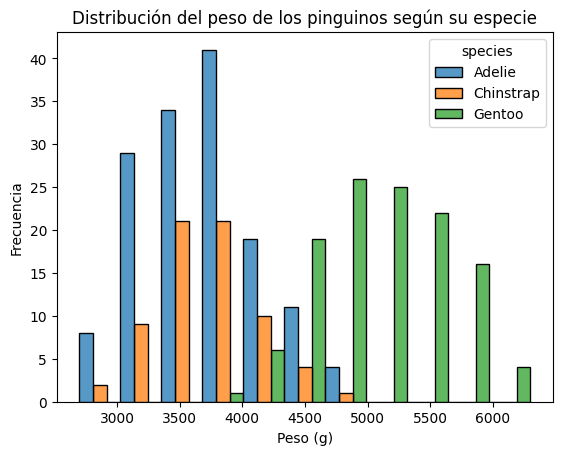

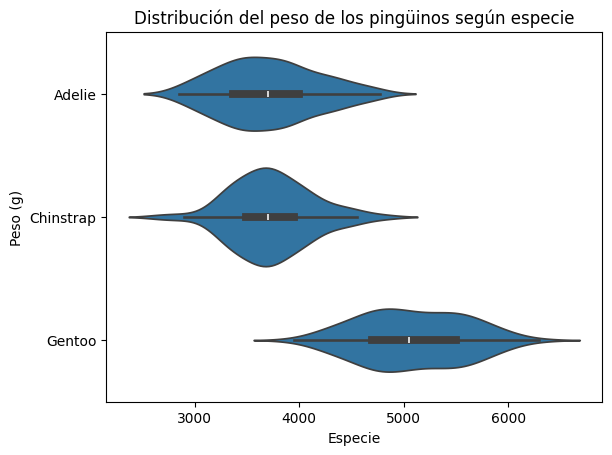

In [2]:
# Distribución del peso de los pinguinos según su especie.
sns.histplot(x='body_mass_g', hue='species', data=penguins, multiple='dodge')
plt.title('Distribución del peso de los pinguinos según su especie')
plt.xlabel('Peso (g)')
plt.ylabel('Frecuencia')
plt.show()

print()

sns.violinplot(x='body_mass_g', y='species', data=penguins)
plt.title('Distribución del peso de los pingüinos según especie')
plt.ylabel('Peso (g)')
plt.xlabel('Especie')
plt.show()



2- Visualizar la distribución de características clave:

Longitud del pìco

Longitud de la aleta

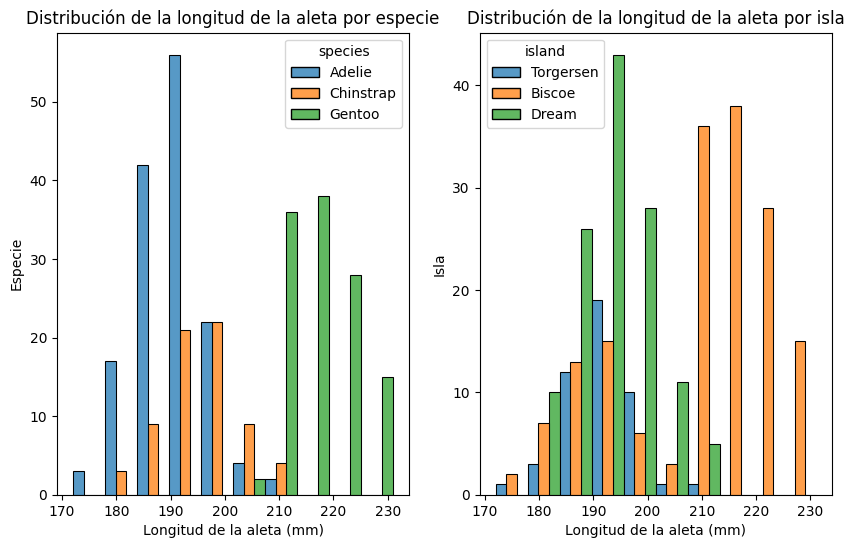

In [3]:
plt.figure(figsize=(10, 6))

# Distribución de la longitud de la aleta en base a la especie
plt.subplot(1, 2, 1)
sns.histplot(x='flipper_length_mm', hue='species', data=penguins, multiple='dodge')
plt.title('Distribución de la longitud de la aleta por especie')
plt.xlabel('Longitud de la aleta (mm)')
plt.ylabel('Especie')

# Distribución de la longitud de la aleta en base a la frecuencia
plt.subplot(1,2,2)
sns.histplot(x='flipper_length_mm', hue='island', data=penguins, multiple='dodge')
plt.title('Distribución de la longitud de la aleta por isla')
plt.xlabel('Longitud de la aleta (mm)')
plt.ylabel('Isla')

plt.show()



In [ ]:
plt.figure(figsize=(10, 6))

# Distribución de la longitud del pico en base a la especie
plt.subplot(1, 2, 1)
sns.histplot(x='bill_length_mm', hue='species', data=penguins, multiple='dodge')
plt.title('Distribución de la longitud del pico por especie')
plt.xlabel('Longitud del pico (mm)')
plt.ylabel('Especie')

# Distribución de la longitud del pico en base a la frecuencia
plt.subplot(1,2,2)
sns.histplot(x='bill_length_mm', hue='island', data=penguins, multiple='dodge')
plt.title('Distribución de la longitud del pico por isla')
plt.xlabel('Longitud del pico (mm)')
plt.ylabel('Isla')

plt.show()


3- Desglosar por ubicación geográfica: Mostrar para cada ubicación, analítica y gráficamente la distribución de:

Ejemplares por sexo

Ejemplares por especie

Desafio: por especie y sexo

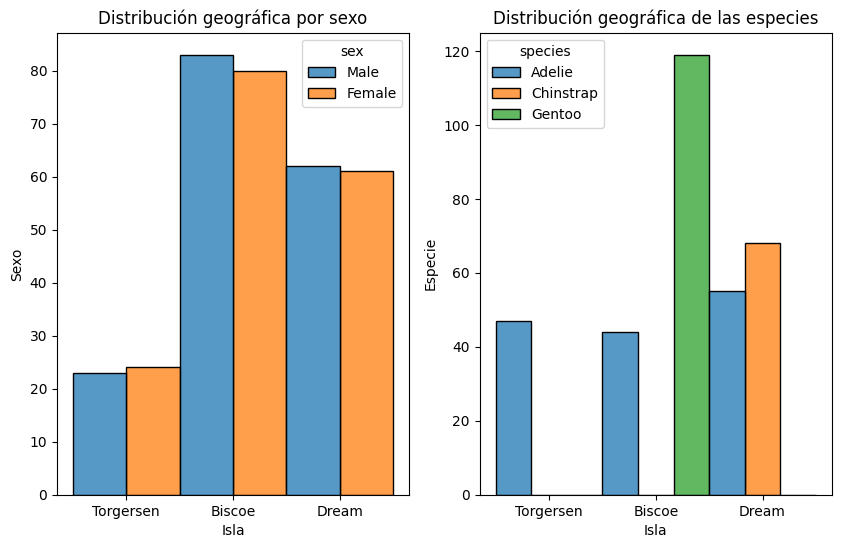

In [4]:
plt.figure(figsize=(10, 6))

# Distribución geográfica por sexo
plt.subplot(1, 2, 1)
sns.histplot(x='island', hue='sex', data=penguins, multiple='dodge')
plt.title('Distribución geográfica por sexo')
plt.xlabel('Isla')
plt.ylabel('Sexo')

# Distribución geográfica de las especies
plt.subplot(1,2,2)
sns.histplot(x='island', hue='species', data=penguins, multiple='dodge')
plt.title('Distribución geográfica de las especies')
plt.xlabel('Isla')
plt.ylabel('Especie')

plt.show()

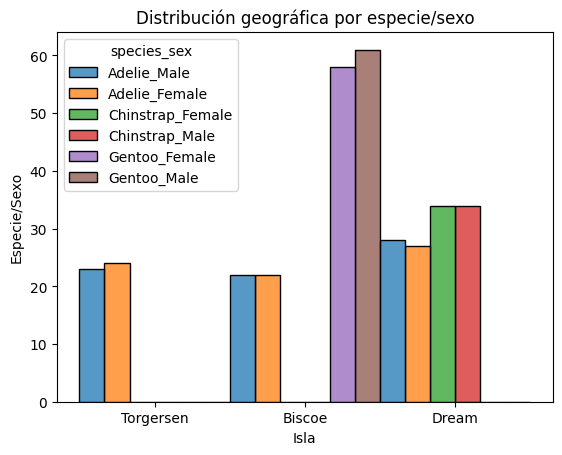

In [5]:
# Crear columna combinada
penguins['species_sex'] = penguins['species'] + '_' + penguins['sex']

# Distribución geográfica por especie/sexo
sns.histplot(x='island', hue='species_sex', data=penguins, multiple='dodge')
plt.title('Distribución geográfica por especie/sexo')
plt.xlabel('Isla')
plt.ylabel('Especie/Sexo')
plt.show()

4- Calcular la matriz de correlación y visualizarla

In [ ]:
penguins.drop(columns=['species', 'island', 'sex', 'species_sex'], errors='ignore', inplace=True)
penguins_matrix_corr = penguins.corr(numeric_only=True)
penguins_matrix_corr

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.228626,0.653096,0.589451
bill_depth_mm,-0.228626,1.000000,-0.577792,-0.472016
flipper_length_mm,0.653096,-0.577792,1.000000,0.872979
body_mass_g,0.589451,-0.472016,0.872979,1.000000


5- Explorar, interpretar y mostrar gráficamente las variables que tienen

Mayor correlación.

Menor correlación.

In [ ]:
# Convertimos la matriz en una tabla de pares
corr_pairs = penguins_matrix_corr.unstack()

# Eliminamos duplicados (porque corr(A,B) = corr(B,A))
corr_pairs = corr_pairs.drop_duplicates()

# Ordenamos de mayor a menor correlación
corr_sorted = corr_pairs.sort_values(ascending=False)

# Eliminar primer elemento (representa una de la diagonales de la matriz de correlación)
corr_sorted = corr_sorted[1:]

# Mostramos las correlaciones más altas y más bajas
print("Mayor correlación:")
print(corr_sorted.head(3))
print("\nMenor correlación:")
print(corr_sorted.tail(3).sort_values(ascending=True))


Mayor correlación:
flipper_length_mm  body_mass_g          0.872979
bill_length_mm     flipper_length_mm    0.653096
                   body_mass_g          0.589451
dtype: float64

Menor correlación:
bill_depth_mm   flipper_length_mm   -0.577792
                body_mass_g         -0.472016
bill_length_mm  bill_depth_mm       -0.228626
dtype: float64


In [ ]:
# Todas las correlaciones
plt.figure(figsize=(8, 6))
sns.heatmap(penguins_matrix_corr, annot=True, cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

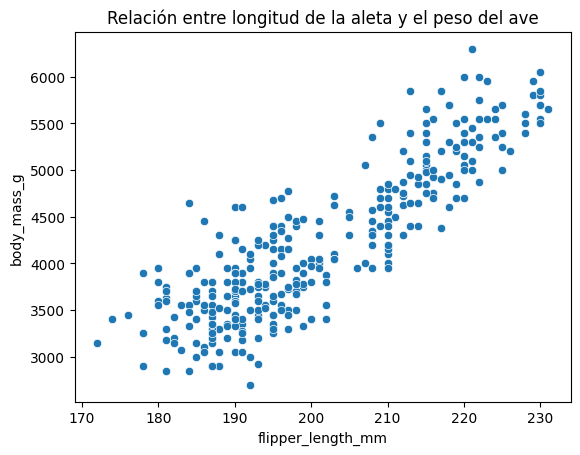

In [ ]:
# Para analizar dos variables específicas (las demayor correlación)
sns.scatterplot(data=penguins, x='flipper_length_mm', y='body_mass_g')
plt.title('Relación entre longitud de la aleta y el peso del ave')
plt.show()

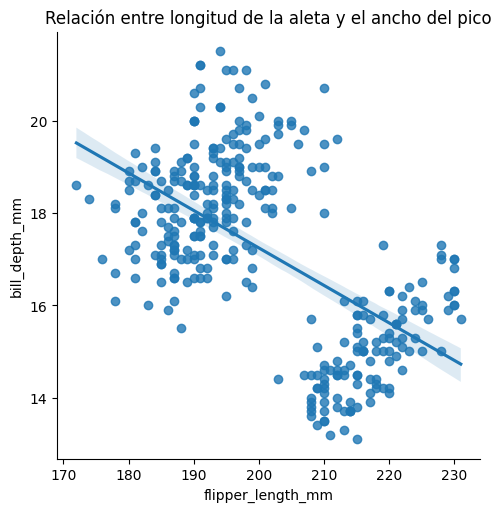

In [ ]:
# Para analizar dos variables específicas (las de menor correlación)
# con línea de tendencia, similar al scatterplot()
sns.lmplot(data=penguins, x='flipper_length_mm', y='bill_depth_mm')
plt.title('Relación entre longitud de la aleta y el ancho del pico')
plt.show()

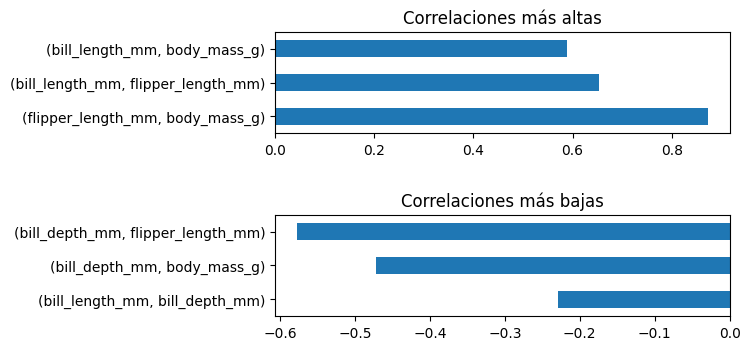

In [ ]:
 # Gráfico de barras
plt.figure(figsize=(8, 4))

plt.subplot(2, 1, 1)
top_corr = corr_sorted.head(3)
top_corr.plot(kind='barh')
plt.title("Correlaciones más altas")

plt.subplot(2, 1, 2)
top_corr = corr_sorted.tail(3)
top_corr.plot(kind='barh')
plt.title("Correlaciones más bajas")

# agrega espacio vertical entre subplots
plt.tight_layout(pad=2.5)
plt.show()
